# SHG intensity map — angular vs frequency detuning

Computes the second-harmonic intensity map

$$
I_{\mathrm{SHG}}(\delta\theta_{\mathrm{SHG}},\,\delta\omega_{\mathrm{SHG}})
=
\iint
\exp\!\left(-\frac{(\delta k_z\, L_{s\!-\!t})^2}{2}\right)
\exp\!\left(-\frac{(\delta k_x\, W)^2}{2}\right)
\left|E_{L,1}(\delta\theta_L,\delta\omega_L)
E_{L,2}(\delta\theta_L,\delta\omega_{SHG}-\delta\omega_L)\right|^2
\,d\delta\theta_L\,d\delta\omega_L
$$

This is a spectral convolution of two fundamental fields at the same input angle.
The displayed SHG-energy detuning is calibrated as
$\delta E_{SHG}^{\rm physical}=2\delta E_{SHG}^{\rm displayed}$.

Following **Theory for SHG code.docx**, with optical constants / Bragg geometry from **SHG base code**,
and a soft transverse phase-match factor $\exp[-(\delta k_x W)^2/2]$ using the beam width $W$.

| Symbol | Meaning |
|--------|---------|
| $\delta\theta_{\mathrm{SHG}}$ | SHG angular deviation from $\theta_{\mathrm{SHG}0}$ |
| $\delta E_{\mathrm{SHG}}$ | SHG energy deviation from $2E_{\mathrm{pump}}$ (eV) |
| $\tau_{TL}$ | 10 fs (used in $L_{s\!-\!t}$ / GVM term) |
| $\Delta E_L$ | fundamental energy FWHM (default **0.45 eV**, independent of $\tau_{TL}$) |
| $W$ | 1 μm (beam width; also sets the $\delta k_x$ envelope) |


In [232]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

HERE = Path.cwd()
CSV_PATH = HERE / "shg_carbon_scattering.csv"
if not CSV_PATH.exists():
    CSV_PATH = HERE / "src" / "shg_carbon_scattering.csv"

print("carbon data:", CSV_PATH)

carbon data: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\shg_carbon_scattering.csv


## 1. Constants and carbon scattering factors

Same definitions as `SHG base code.nb`.

In [233]:
c = 299_792_458.0
hb = 1.0545715964207855e-34
q = 1.602e-19
a0 = 3.5668e-10
den = 8.0 / a0**3
G = np.sqrt(1.0**2 + 1.0**2 + 3.0**2) * 2.0 * np.pi / a0
re = 2.82e-13 * 1e-2  # classical electron radius [m]

carbon = pd.read_csv(CSV_PATH)
omega_tab = carbon["omega_rad_s"].to_numpy(float)
f1_tab = carbon["f1"].to_numpy(float)
f2_tab = carbon["f2"].to_numpy(float)

f1 = interp1d(omega_tab, f1_tab, kind="cubic", fill_value="extrapolate")
f2 = interp1d(omega_tab, f2_tab, kind="cubic", fill_value="extrapolate")


def n_index(w):
    """Refractive index n(ω) from carbon f1 (base code)."""
    w = np.asarray(w, dtype=float)
    return 1.0 - den * re * 2.0 * np.pi * c**2 / w**2 * f1(w)


def alpha_loss(w):
    """Amplitude absorption coefficient α(ω) from carbon f2."""
    w = np.asarray(w, dtype=float)
    return w / c * den * re * 2.0 * np.pi * c**2 / w**2 * f2(w)


def k_wave(w):
    return np.asarray(w, dtype=float) * n_index(w) / c

## 2. Pump / SHG base geometry

Solve transverse + longitudinal momentum matching at nominal frequencies
(Laue geometry with reciprocal-lattice vector $G$), as in the base notebook.

In [234]:
pump_photon_energy_eV = 9.817e3
w_LASER = pump_photon_energy_eV * q / hb
w_SHG = 2.0 * w_LASER
E_SHG0_eV = 2.0 * pump_photon_energy_eV

k_LASER = float(k_wave(w_LASER))
k_SHG = float(k_wave(w_SHG))

# Bragg estimate, then exact solve of (eq1, eq2) from base code
theta_B = abs(np.arcsin(G / (2.0 * k_SHG)))


def momentum_residuals(theta_L, theta_S):
    eq1 = 2.0 * k_LASER * np.sin(theta_L) + G - k_SHG * np.sin(theta_S)
    eq2 = 2.0 * k_LASER * np.cos(theta_L) - k_SHG * np.cos(theta_S)
    return eq1, eq2


def solve_base_angles(theta_L_guess=-theta_B, theta_S_guess=theta_B, n_iter=40):
    """Newton solve for phase-matched (θ_LASER0, θ_SHG0)."""
    th_L = float(theta_L_guess)
    th_S = float(theta_S_guess)
    for _ in range(n_iter):
        r1, r2 = momentum_residuals(th_L, th_S)
        # Jacobian
        J = np.array(
            [
                [2.0 * k_LASER * np.cos(th_L), -k_SHG * np.cos(th_S)],
                [-2.0 * k_LASER * np.sin(th_L), k_SHG * np.sin(th_S)],
            ],
            dtype=float,
        )
        delta = np.linalg.solve(J, -np.array([r1, r2], dtype=float))
        th_L += delta[0]
        th_S += delta[1]
        if np.linalg.norm(delta) < 1e-14:
            break
    return th_L, th_S


theta_LASER0, theta_SHG0 = solve_base_angles()
rho = theta_SHG0 - theta_LASER0  # walk-off angle used in GVM / L_{s-t}

print(f"θ_B = {theta_B:.6f} rad ({np.degrees(theta_B):.4f} deg)")
print(f"θ_LASER0 = {theta_LASER0:.6f} rad ({np.degrees(theta_LASER0):.4f} deg)")
print(f"θ_SHG0   = {theta_SHG0:.6f} rad ({np.degrees(theta_SHG0):.4f} deg)")
print(f"ρ = θ_SHG0 - θ_LASER0 = {rho:.6f} rad")
print(f"E_pump = {pump_photon_energy_eV:.3f} eV,  E_SHG0 = {E_SHG0_eV:.3f} eV")

θ_B = 0.298017 rad (17.0751 deg)
θ_LASER0 = -0.298009 rad (-17.0747 deg)
θ_SHG0   = 0.298027 rad (17.0757 deg)
ρ = θ_SHG0 - θ_LASER0 = 0.596036 rad
E_pump = 9817.000 eV,  E_SHG0 = 19634.000 eV


## 3. Group velocities, GVM, $L_{s\!-\!t}$, laser envelope

From the theory document:

$$
v_{g}=\left(\frac{dk}{d\omega}\right)^{-1},
\qquad
\mathrm{GVM}=\frac{1}{v_{g,\mathrm{SHG}}\cos\rho}-\frac{1}{v_{g,\mathrm{LASER}}}
$$

$$
L_{s\!-\!t}
=\left(\frac{\tan^2\rho}{W^2}+\frac{\mathrm{GVM}^2}{\tau_{TL}^2}\right)^{-1/2},
\qquad
\Delta\theta=\frac{2}{k_{\mathrm{LASER}}W}
$$

The two fundamental fields have identical Gaussian shapes but separate frequency arguments:

$$
E_{L,j}(\delta\theta_L,\delta\omega_{L,j})
=\exp\!\left(-\frac{\delta\theta_L^2}{\Delta\theta^2}\right)
\exp\!\left(-\frac{\delta\omega_{L,j}^2\tau_{\mathrm{spec}}^2}{4\ln 2}\right),\quad j=1,2.
$$

The SHG source uses their product with
$\delta\omega_{L,2}=\delta\omega_S-\delta\omega_{L,1}$.

- $\tau_{TL}$: temporal scale in $L_{s\!-\!t}$ (kept at 10 fs).
- $\tau_{\mathrm{spec}}$: spectral scale in $E_{\mathrm{LASER}}$.
  - If `SPECTRAL_WIDTH_FROM_TAU_TL = True`: $\tau_{\mathrm{spec}}=\tau_{TL}$ (old transform-limited option).
  - If `False` (default): set by independent fundamental energy FWHM $\Delta E_L=0.45\,\mathrm{eV}$.


In [235]:
W = 1.0e-6          # m  (theory)
TAU_TL = 10.0e-15   # s  (used in L_s-t / GVM term)

# Spectral width of each fundamental field
SPECTRAL_WIDTH_FROM_TAU_TL = False   # True: old TL link; False: set ΔE_L independently
FUND_E_FWHM_eV_SETTING = 0.45        # intensity FWHM of each |E_LASER,j|^2 [eV]

# SHG-energy calibration:
# physical/internal δE_SHG = 2 × displayed δE_SHG, so displayed values are half.
SHG_ENERGY_CALIBRATION = 2.0


def displayed_dE_to_dw_SHG(dE_display_eV):
    return SHG_ENERGY_CALIBRATION * np.asarray(dE_display_eV) * q / hb


def dw_SHG_to_displayed_dE(dw_SHG):
    return np.asarray(dw_SHG) * hb / (q * SHG_ENERGY_CALIBRATION)


if SPECTRAL_WIDTH_FROM_TAU_TL:
    TAU_SPEC = TAU_TL
    fund_E_FWHM_eV = (2.0 * np.sqrt(2.0) * np.log(2.0) / TAU_SPEC) * hb / q
else:
    fund_E_FWHM_eV = float(FUND_E_FWHM_eV_SETTING)
    # |E|^2 ~ exp(-dw^2 τ_spec^2 / (2 ln 2))  =>  Δω_FWHM = 2√2 ln2 / τ_spec
    delta_omega_L_FWHM = fund_E_FWHM_eV * q / hb
    TAU_SPEC = 2.0 * np.sqrt(2.0) * np.log(2.0) / delta_omega_L_FWHM


def group_velocity(w0, rel_step=1e-6):
    """v_g(ω) = 1 / (dk/dω) by central finite difference."""
    w0 = float(w0)
    dw = rel_step * w0
    dk_dw = (k_wave(w0 + dw) - k_wave(w0 - dw)) / (2.0 * dw)
    return 1.0 / float(dk_dw)


vg_LASER = group_velocity(w_LASER)
vg_SHG = group_velocity(w_SHG)
GVM = 1.0 / (vg_SHG * np.cos(rho)) - 1.0 / vg_LASER

L_st = (np.tan(rho) ** 2 / W**2 + GVM**2 / TAU_TL**2) ** (-0.5)
Delta_theta = 2.0 / (k_LASER * W)

print(f"vg_LASER = {vg_LASER:.6e} m/s")
print(f"vg_SHG   = {vg_SHG:.6e} m/s")
print(f"GVM      = {GVM:.6e} s/m")
print(f"L_s-t    = {L_st:.6e} m")
print(f"Δθ       = {Delta_theta:.6e} rad ({Delta_theta*1e6:.3f} μrad)")
print(f"TAU_TL   = {TAU_TL*1e15:.1f} fs  (for L_s-t)")
print(
    f"SPECTRAL_WIDTH_FROM_TAU_TL = {SPECTRAL_WIDTH_FROM_TAU_TL} | "
    f"ΔE_L FWHM = {fund_E_FWHM_eV:.4g} eV | "
    f"TAU_SPEC = {TAU_SPEC*1e15:.4g} fs"
)


vg_LASER = 2.997902e+08 m/s
vg_SHG   = 2.997919e+08 m/s
GVM      = 6.950002e-10 s/m
L_s-t    = 1.466523e-06 m
Δθ       = 4.020581e-05 rad (40.206 μrad)
TAU_TL   = 10.0 fs  (for L_s-t)
SPECTRAL_WIDTH_FROM_TAU_TL = False | ΔE_L FWHM = 0.45 eV | TAU_SPEC = 2.868 fs


## 4. Phase mismatch $\delta k_z$ and $\delta k_x$

The two fundamental fields share the same input angle but have separate frequencies:

$$
\delta\omega_{L,1}=\delta\omega_L,\qquad
\delta\omega_{L,2}=\delta\omega_S-\delta\omega_L,
$$

so that $\omega_1+\omega_2=\omega_S$. The phase mismatches are

$$
\begin{aligned}
\delta k_x
&= k(\omega_1)\sin(\theta_{L0}+\delta\theta_L)
 + k(\omega_2)\sin(\theta_{L0}+\delta\theta_L)+G
 - k(\omega_S)\sin(\theta_{S0}+\delta\theta_S), \\
\delta k_z
&= k(\omega_1)\cos(\theta_{L0}+\delta\theta_L)
 + k(\omega_2)\cos(\theta_{L0}+\delta\theta_L)
 - k(\omega_S)\cos(\theta_{S0}+\delta\theta_S).
\end{aligned}
$$

The SHG intensity uses **both** envelopes

$$
\exp\!\left[-\frac{(\delta k_z L_{s\!-\!t})^2}{2}\right]
\exp\!\left[-\frac{(\delta k_x W)^2}{2}\right],
$$

with the same beam width $W$ as in $\Delta\theta$ and $L_{s\!-\!t}$.


In [236]:
def delta_kz(dtheta_L, dw_L1, dtheta_S, dw_S):
    """Longitudinal mismatch for ω1+ω2=ωSHG; dw_L2=dw_S-dw_L1."""
    dw_L2 = dw_S - dw_L1
    wL1 = w_LASER + dw_L1
    wL2 = w_LASER + dw_L2
    wS = w_SHG + dw_S
    theta_L = theta_LASER0 + dtheta_L  # both fundamental fields enter at this angle
    return (
        k_wave(wL1) * np.cos(theta_L)
        + k_wave(wL2) * np.cos(theta_L)
        - k_wave(wS) * np.cos(theta_SHG0 + dtheta_S)
    )


def delta_kx(dtheta_L, dw_L1, dtheta_S, dw_S):
    """Transverse mismatch for ω1+ω2=ωSHG; dw_L2=dw_S-dw_L1."""
    dw_L2 = dw_S - dw_L1
    wL1 = w_LASER + dw_L1
    wL2 = w_LASER + dw_L2
    wS = w_SHG + dw_S
    theta_L = theta_LASER0 + dtheta_L
    return (
        k_wave(wL1) * np.sin(theta_L)
        + k_wave(wL2) * np.sin(theta_L)
        + G
        - k_wave(wS) * np.sin(theta_SHG0 + dtheta_S)
    )


def shg_phase_envelope(dtheta_L, dw_L1, dtheta_S, dw_S, L_st_val, W_val=None):
    """Combined longitudinal + transverse phase-match envelope."""
    if W_val is None:
        W_val = W
    dkz = delta_kz(dtheta_L, dw_L1, dtheta_S, dw_S)
    dkx = delta_kx(dtheta_L, dw_L1, dtheta_S, dw_S)
    return np.exp(-0.5 * (dkz * L_st_val) ** 2) * np.exp(-0.5 * (dkx * W_val) ** 2)


def E_laser_amp_1(dtheta_L, dw_L1, Delta_theta_val=None, tau_spec_val=None):
    """First fundamental-field amplitude E_L,1(δθ_L, δω_L1)."""
    if Delta_theta_val is None:
        Delta_theta_val = Delta_theta
    if tau_spec_val is None:
        tau_spec_val = TAU_SPEC
    return np.exp(-(dtheta_L**2) / Delta_theta_val**2) * np.exp(
        -(dw_L1**2) * tau_spec_val**2 / (4.0 * np.log(2.0))
    )


def E_laser_amp_2(dtheta_L, dw_L2, Delta_theta_val=None, tau_spec_val=None):
    """Second fundamental-field amplitude E_L,2(δθ_L, δω_L2)."""
    return E_laser_amp_1(dtheta_L, dw_L2, Delta_theta_val, tau_spec_val)


def laser_pair_intensity(dtheta_L, dw_L1, dw_S, Delta_theta_val=None, tau_spec_val=None):
    """Convolution weight |E_L,1(δω1) E_L,2(δωS-δω1)|²."""
    dw_L2 = dw_S - dw_L1
    pair_amp = E_laser_amp_1(dtheta_L, dw_L1, Delta_theta_val, tau_spec_val) * E_laser_amp_2(
        dtheta_L, dw_L2, Delta_theta_val, tau_spec_val
    )
    return np.abs(pair_amp) ** 2


# Sanity: exact phase match at nominal point
print("δkx(0)=", float(delta_kx(0, 0, 0, 0)))
print("δkz(0)=", float(delta_kz(0, 0, 0, 0)))
print("envelope(0)=", float(shg_phase_envelope(0, 0, 0, 0, L_st)))


δkx(0)= 3.814697265625e-06
δkz(0)= 0.0
envelope(0)= 1.0


## 5. Intensity map $I_{\mathrm{SHG}}(\delta\theta_{\mathrm{SHG}},\,\delta E_{\mathrm{SHG}})$

Every map point is obtained from the convolution of two fundamental fields over
$(\delta\theta_L,\delta\omega_{L,1})$:

$$
\begin{aligned}
I_{\mathrm{SHG}}(\delta\theta_S,\delta E_S^{\mathrm{disp}})
=\iint &\exp\!\left[-\frac{(\delta k_z L_{s\!-\!t})^2}{2}\right]
\exp\!\left[-\frac{(\delta k_x W)^2}{2}\right]\\
&\times\left|E_{L,1}(\delta\theta_L,\delta\omega_{L,1})
E_{L,2}(\delta\theta_L,\delta\omega_S-\delta\omega_{L,1})\right|^2
\,d\delta\theta_L\,d\delta\omega_{L,1}.
\end{aligned}
$$

Both fundamental fields enter at the same laser angle. The displayed SHG-energy axis is calibrated by

$$
\delta E_S^{\mathrm{physical}}=2\,\delta E_S^{\mathrm{disp}},\qquad
\delta\omega_S=\frac{2q\,\delta E_S^{\mathrm{disp}}}{\hbar},
$$

so all displayed SHG-energy detunings and widths are half their internal physical values.
$W$ is the beam width (soft $\delta k_x\!\approx\!0$ constraint).


In [237]:
# ---- map / integration resolution (adjust if needed) ----
N_THETA_SHG = 121
N_ENERGY_SHG = 121
N_THETA_L = 61
N_OMEGA_L = 61

# Characteristic laser widths (spectrum from TAU_SPEC)
sigma_theta_L = Delta_theta / np.sqrt(2.0)  # from exp(-θ²/Δθ²) amplitude
sigma_w_L = np.sqrt(2.0 * np.log(2.0)) / TAU_SPEC  # |E|^2 1/e half-width in ω

# SHG map ranges: a few times the phase-match acceptance
theta_accept = 1.0 / (abs(k_SHG * np.sin(theta_SHG0)) * L_st + 1e-30)
w_accept = 1.0 / (L_st / c + 1e-30)
E_accept_display_eV = float(dw_SHG_to_displayed_dE(w_accept))

# The displayed range is half the internal/physical SHG-energy range.
MAP_RANGE_SCALE = 4.0
dtheta_SHG_max = MAP_RANGE_SCALE * 4.0 * max(theta_accept, Delta_theta)
dE_SHG_max_eV = MAP_RANGE_SCALE * 4.0 * max(
    E_accept_display_eV,
    sigma_w_L * hb / (q * SHG_ENERGY_CALIBRATION),
    fund_E_FWHM_eV / SHG_ENERGY_CALIBRATION,
)

dtheta_SHG_axis = np.linspace(-dtheta_SHG_max, dtheta_SHG_max, N_THETA_SHG)
dE_SHG_axis_eV = np.linspace(-dE_SHG_max_eV, dE_SHG_max_eV, N_ENERGY_SHG)
dw_SHG_axis = displayed_dE_to_dw_SHG(dE_SHG_axis_eV)

dtheta_L_axis = np.linspace(-3.0 * Delta_theta, 3.0 * Delta_theta, N_THETA_L)
# Relative convolution coordinate: δω_L1 = δω_SHG/2 + δω_rel.
dw_L_axis = np.linspace(-3.0 * sigma_w_L, 3.0 * sigma_w_L, N_OMEGA_L)

DTH_L, DW_REL = np.meshgrid(dtheta_L_axis, dw_L_axis, indexing="ij")
# Backward-compatible alias; loops shift it by δω_SHG/2 before evaluation.
DW_L = DW_REL
dth_L = dtheta_L_axis[1] - dtheta_L_axis[0]
dw_L = dw_L_axis[1] - dw_L_axis[0]

print(f"SHG θ range: ±{dtheta_SHG_max*1e6:.2f} μrad")
print(
    f"Displayed SHG E range: ±{dE_SHG_max_eV:.4f} eV "
    f"(internal physical range: ±{SHG_ENERGY_CALIBRATION*dE_SHG_max_eV:.4f} eV)"
)
print(
    f"Each laser field: ΔE_L FWHM = {fund_E_FWHM_eV:.4g} eV, "
    f"σ_E,L = {sigma_w_L * hb / q:.4g} eV"
)
print(f"Integration grid: {N_THETA_L} × {N_OMEGA_L}, map: {N_THETA_SHG} × {N_ENERGY_SHG}")


SHG θ range: ±643.29 μrad
Displayed SHG E range: ±3.6000 eV (internal physical range: ±7.2000 eV)
Each laser field: ΔE_L FWHM = 0.45 eV, σ_E,L = 0.2703 eV
Integration grid: 61 × 61, map: 121 × 121


## 6. Parameter table

All constants, geometry, derived quantities, and numerical-grid settings used above.

In [238]:
param_rows = [
    # --- physical constants (SHG base code) ---
    ("c", c, "m/s", "speed of light"),
    ("ℏ (hb)", hb, "J·s", "reduced Planck constant"),
    ("q", q, "C", "elementary charge"),
    ("a0", a0, "m", "diamond lattice constant"),
    ("den", den, "1/m³", "atom number density = 8/a0³"),
    ("G", G, "1/m", "reciprocal-lattice vector |G|(113)"),
    ("re", re, "m", "classical electron radius"),
    # --- pump / SHG ---
    ("E_pump", pump_photon_energy_eV, "eV", "pump photon energy"),
    ("E_SHG0", E_SHG0_eV, "eV", "nominal SHG energy = 2 E_pump"),
    ("ω_LASER", w_LASER, "rad/s", "pump angular frequency"),
    ("ω_SHG", w_SHG, "rad/s", "SHG angular frequency"),
    ("k_LASER", k_LASER, "1/m", "pump wave number"),
    ("k_SHG", k_SHG, "1/m", "SHG wave number"),
    ("n(ω_LASER)", float(n_index(w_LASER)), "—", "refractive index at pump"),
    ("n(ω_SHG)", float(n_index(w_SHG)), "—", "refractive index at SHG"),
    # --- geometry ---
    ("θ_B", theta_B, "rad", "Bragg angle estimate"),
    ("θ_B", np.degrees(theta_B), "deg", "Bragg angle estimate"),
    ("θ_LASER0", theta_LASER0, "rad", "phase-matched pump angle"),
    ("θ_LASER0", np.degrees(theta_LASER0), "deg", "phase-matched pump angle"),
    ("θ_SHG0", theta_SHG0, "rad", "phase-matched SHG angle"),
    ("θ_SHG0", np.degrees(theta_SHG0), "deg", "phase-matched SHG angle"),
    ("ρ", rho, "rad", "walk-off angle = θ_SHG0 − θ_LASER0"),
    ("ρ", np.degrees(rho), "deg", "walk-off angle"),
    # --- envelope / walk-off (theory) ---
    ("W", W, "m", "beam width (theory)"),
    ("W", W * 1e6, "μm", "beam width (theory)"),
    ("τ_TL", TAU_TL, "s", "temporal scale in L_s-t (GVM term)"),
    ("τ_TL", TAU_TL * 1e15, "fs", "temporal scale in L_s-t (GVM term)"),
    ("SPECTRAL_FROM_TAU_TL", SPECTRAL_WIDTH_FROM_TAU_TL, "—", "if True, spectrum from τ_TL"),
    ("ΔE_L FWHM", fund_E_FWHM_eV, "eV", "intensity spectral FWHM of each fundamental field"),
    ("τ_spec", TAU_SPEC, "s", "spectral Gaussian scale in E_L,1 and E_L,2"),
    ("τ_spec", TAU_SPEC * 1e15, "fs", "spectral Gaussian scale in E_L,1 and E_L,2"),
    ("SHG energy calibration", SHG_ENERGY_CALIBRATION, "—", "physical/displayed δE_SHG ratio"),
    ("v_g,LASER", vg_LASER, "m/s", "pump group velocity"),
    ("v_g,SHG", vg_SHG, "m/s", "SHG group velocity"),
    ("GVM", GVM, "s/m", "1/(v_g,SHG cos ρ) − 1/v_g,LASER"),
    ("L_s-t", L_st, "m", "spatiotemporal interaction length"),
    ("L_s-t", L_st * 1e6, "μm", "spatiotemporal interaction length"),
    ("Δθ", Delta_theta, "rad", "laser angular width = 2/(k_LASER W)"),
    ("Δθ", Delta_theta * 1e6, "μrad", "laser angular width"),
    ("σ_ω,L", sigma_w_L, "rad/s", "laser freq. scale √(2 ln 2)/τ_spec"),
    ("σ_E,L", sigma_w_L * hb / q, "eV", "laser energy scale"),
    # --- map ranges ---
    ("δθ_SHG max", dtheta_SHG_max, "rad", "SHG angular map half-range"),
    ("δθ_SHG max", dtheta_SHG_max * 1e6, "μrad", "SHG angular map half-range"),
    ("δE_SHG max", dE_SHG_max_eV, "eV", "SHG energy map half-range"),
    # --- numerical grid ---
    ("N_θ,SHG", N_THETA_SHG, "—", "SHG angle map samples"),
    ("N_E,SHG", N_ENERGY_SHG, "—", "SHG energy map samples"),
    ("N_θ,L", N_THETA_L, "—", "laser angle integration samples"),
    ("N_ω,L", N_OMEGA_L, "—", "laser frequency integration samples"),
    ("carbon points", len(carbon), "—", "f1/f2 interpolation table size"),
]

params_df = pd.DataFrame(param_rows, columns=["Parameter", "Value", "Unit", "Description"])
params_df["Value"] = params_df["Value"].map(
    lambda v: f"{v:.6g}" if isinstance(v, (float, np.floating)) else str(v)
)

# nicer display in Jupyter
try:
    from IPython.display import display
    display(params_df)
except ImportError:
    print(params_df.to_string(index=False))

# also print a compact text table
print("\n" + params_df.to_string(index=False))


,Parameter,Value,Unit,Description
0,c,2.99792e+08,m/s,speed of light
1,ℏ (hb),1.05457e-34,J·s,reduced Planck constant
2,q,1.602e-19,C,elementary charge
3,a0,3.5668e-10,m,diamond lattice constant
4,den,1.76301e+29,1/m³,atom number density = 8/a0³
5,G,5.84248e+10,1/m,reciprocal-lattice vector |G|(113)
6,re,2.82e-15,m,classical electron radius
7,E_pump,9817,eV,pump photon energy
8,E_SHG0,19634,eV,nominal SHG energy = 2 E_pump
9,ω_LASER,1.4913e+19,rad/s,pump angular frequency



             Parameter       Value  Unit                                       Description
                     c 2.99792e+08   m/s                                    speed of light
                ℏ (hb) 1.05457e-34   J·s                           reduced Planck constant
                     q   1.602e-19     C                                 elementary charge
                    a0  3.5668e-10     m                          diamond lattice constant
                   den 1.76301e+29  1/m³                       atom number density = 8/a0³
                     G 5.84248e+10   1/m                reciprocal-lattice vector |G|(113)
                    re    2.82e-15     m                         classical electron radius
                E_pump        9817    eV                                pump photon energy
                E_SHG0       19634    eV                     nominal SHG energy = 2 E_pump
               ω_LASER  1.4913e+19 rad/s                            pump angular frequenc

In [239]:
I_SHG = np.zeros((N_ENERGY_SHG, N_THETA_SHG), dtype=float)

for i_E, dw_S in enumerate(dw_SHG_axis):
    # Center the convolution grid at δω_L1=δω_SHG/2.
    DW_L1 = DW_REL + 0.5 * dw_S
    pair_weight = laser_pair_intensity(DTH_L, DW_L1, dw_S)
    for i_th, dth_S in enumerate(dtheta_SHG_axis):
        envelope = shg_phase_envelope(DTH_L, DW_L1, dth_S, dw_S, L_st, W)
        I_SHG[i_E, i_th] = np.sum(envelope * pair_weight) * dth_L * dw_L

I_SHG_norm = I_SHG / np.max(I_SHG)

print(f"max I_SHG (raw) = {np.max(I_SHG):.6e}")
print(f"using δkz envelope with L_s-t = {L_st*1e6:.4g} μm and δkx envelope with W = {W*1e6:.4g} μm")
print("map done.")


max I_SHG (raw) = 1.025140e+10
using δkz envelope with L_s-t = 1.467 μm and δkx envelope with W = 1 μm
map done.


## 7. Plot

Plot window: δθ_SHG ∈ ±34.31 μrad, δE_SHG ∈ ±0.4800 eV (from I ≥ 5% support, pad×1.6)


<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
C:\Users\SharonLab\AppData\Local\Temp\ipykernel_10564\3624607405.py:54: SyntaxWarning: invalid escape sequence '\m'
  + f"$E_{{\mathrm{{pump}}}}={pump_photon_energy_eV/1e3:.3f}$ keV"


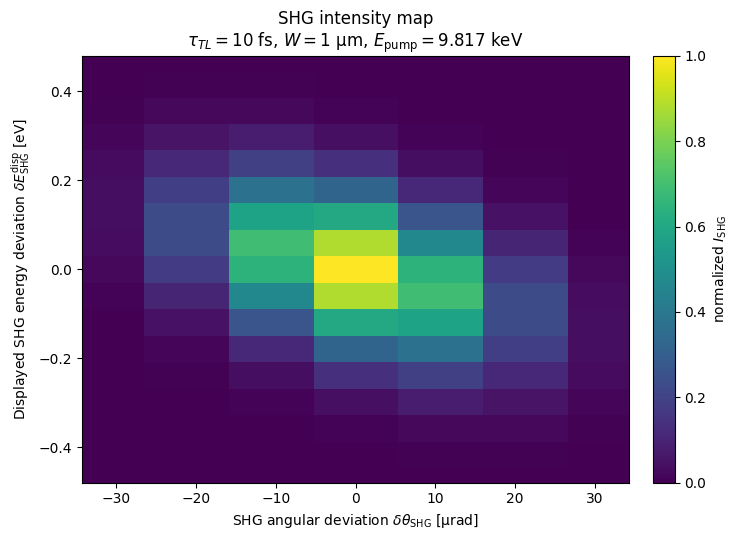

In [240]:
# Sensible display window from the computed map (where I >= fraction of peak)
PLOT_FRAC = 0.05          # contour used to define the signal support
PLOT_PAD = 1.6            # pad the bounding box

_mask = I_SHG_norm >= PLOT_FRAC
if np.any(_mask):
    _iy, _ix = np.where(_mask)
    _th = dtheta_SHG_axis[_ix]
    _E = dE_SHG_axis_eV[_iy]
    dtheta_plot_max = PLOT_PAD * max(abs(_th.min()), abs(_th.max()))
    dE_plot_max = PLOT_PAD * max(abs(_E.min()), abs(_E.max()))
else:
    # fallback: a few acceptance / laser scales on the displayed axis
    dtheta_plot_max = 6.0 * max(Delta_theta, 1.0 / (abs(k_SHG * np.cos(theta_SHG0)) * W))
    dE_plot_max = 6.0 * (sigma_w_L * hb / (q * SHG_ENERGY_CALIBRATION))

# keep inside the computed grid
dtheta_plot_max = min(dtheta_plot_max, abs(dtheta_SHG_axis).max())
dE_plot_max = min(dE_plot_max, abs(dE_SHG_axis_eV).max())

print(
    f"Plot window: δθ_SHG ∈ ±{dtheta_plot_max*1e6:.2f} μrad, "
    f"δE_SHG ∈ ±{dE_plot_max:.4f} eV "
    f"(from I ≥ {PLOT_FRAC:.0%} support, pad×{PLOT_PAD:g})"
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

extent = [
    dtheta_SHG_axis[0] * 1e6,
    dtheta_SHG_axis[-1] * 1e6,
    dE_SHG_axis_eV[0],
    dE_SHG_axis_eV[-1],
]
im = ax.imshow(
    I_SHG_norm,
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="viridis",
)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r"normalized $I_{\mathrm{SHG}}$")

ax.set_xlim(-dtheta_plot_max * 1e6, dtheta_plot_max * 1e6)
ax.set_ylim(-dE_plot_max, dE_plot_max)

ax.set_xlabel(r"SHG angular deviation $\delta\theta_{\mathrm{SHG}}$ [μrad]")
ax.set_ylabel(r"Displayed SHG energy deviation $\delta E_{\mathrm{SHG}}^{\mathrm{disp}}$ [eV]")
ax.set_title(
    r"SHG intensity map"
    + f"\n$\\tau_{{TL}}={TAU_TL*1e15:.0f}$ fs, "
    + f"$W={W*1e6:.0f}$ μm, "
    + f"$E_{{\mathrm{{pump}}}}={pump_photon_energy_eV/1e3:.3f}$ keV"
)
fig.tight_layout()
plt.show()


=== Parameters for this intensity map / lineouts ===
TAU_TL   = 10 fs  (L_s-t only)
SPECTRAL_WIDTH_FROM_TAU_TL = False
TAU_SPEC = 2.868 fs
L_s-t    = 1.46652 um  (1.466523e-06 m)
Fundamental angular FWHM  dth_L = 47.3387 urad
Fundamental energy FWHM   dE_L  = 0.45 eV
Plot window: δθ_SHG ∈ ±34.31 μrad, δE_SHG ∈ ±0.4800 eV

=== Integration (fundamental-field deviations only) ===
Integrated variables: dtheta_LASER, domega_LASER
dtheta_LASER range: [-120.617, 120.617] urad (N = 61)
domega_rel range: [-1.231622e+15, 1.231622e+15] rad/s (N = 61), with domega_L1 = domega_SHG/2 + domega_rel
domega_rel as energy: [-0.810758, 0.810758] eV
SHG calibration: physical deltaE_SHG = 2 × displayed deltaE_SHG


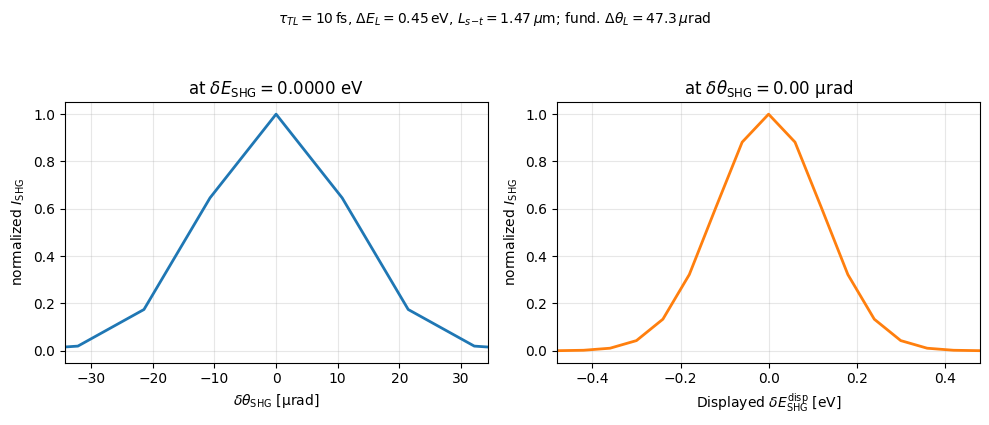

In [241]:
# Lineouts through the map center
i0 = N_ENERGY_SHG // 2
j0 = N_THETA_SHG // 2

# --- Fundamental-field widths ---
fund_ang_FWHM_urad = Delta_theta * np.sqrt(2.0 * np.log(2.0)) * 1e6
# fund_E_FWHM_eV already set in Sec. 3 from SPECTRAL_WIDTH_FROM_TAU_TL / FUND_E_FWHM_eV_SETTING

# Reuse / recompute the same sensible plot window as the 2D map
if "dtheta_plot_max" not in globals() or "dE_plot_max" not in globals():
    PLOT_FRAC = 0.05
    PLOT_PAD = 1.6
    _mask = I_SHG_norm >= PLOT_FRAC
    if np.any(_mask):
        _iy, _ix = np.where(_mask)
        _th = dtheta_SHG_axis[_ix]
        _E = dE_SHG_axis_eV[_iy]
        dtheta_plot_max = PLOT_PAD * max(abs(_th.min()), abs(_th.max()))
        dE_plot_max = PLOT_PAD * max(abs(_E.min()), abs(_E.max()))
    else:
        dtheta_plot_max = 6.0 * max(Delta_theta, 1.0 / (abs(k_SHG * np.cos(theta_SHG0)) * W))
        dE_plot_max = 6.0 * max(
            sigma_w_L * hb / (q * SHG_ENERGY_CALIBRATION),
            fund_E_FWHM_eV / SHG_ENERGY_CALIBRATION,
        )
    dtheta_plot_max = min(dtheta_plot_max, abs(dtheta_SHG_axis).max())
    dE_plot_max = min(dE_plot_max, abs(dE_SHG_axis_eV).max())

print("=== Parameters for this intensity map / lineouts ===")
print(f"TAU_TL   = {TAU_TL * 1e15:.4g} fs  (L_s-t only)")
print(f"SPECTRAL_WIDTH_FROM_TAU_TL = {SPECTRAL_WIDTH_FROM_TAU_TL}")
print(f"TAU_SPEC = {TAU_SPEC * 1e15:.4g} fs")
print(f"L_s-t    = {L_st * 1e6:.6g} um  ({L_st:.6e} m)")
print(f"Fundamental angular FWHM  dth_L = {fund_ang_FWHM_urad:.6g} urad")
print(f"Fundamental energy FWHM   dE_L  = {fund_E_FWHM_eV:.6g} eV")
print(
    f"Plot window: δθ_SHG ∈ ±{dtheta_plot_max*1e6:.2f} μrad, "
    f"δE_SHG ∈ ±{dE_plot_max:.4f} eV"
)
print()
print("=== Integration (fundamental-field deviations only) ===")
print("Integrated variables: dtheta_LASER, domega_LASER")
print(
    f"dtheta_LASER range: [{dtheta_L_axis[0]*1e6:.6g}, {dtheta_L_axis[-1]*1e6:.6g}] urad "
    f"(N = {len(dtheta_L_axis)})"
)
print(
    f"domega_rel range: [{dw_L_axis[0]:.6e}, {dw_L_axis[-1]:.6e}] rad/s "
    f"(N = {len(dw_L_axis)}), with domega_L1 = domega_SHG/2 + domega_rel"
)
print(
    f"domega_rel as energy: [{dw_L_axis[0]*hb/q:.6g}, {dw_L_axis[-1]*hb/q:.6g}] eV"
)
print(
    f"SHG calibration: physical deltaE_SHG = {SHG_ENERGY_CALIBRATION:g} × displayed deltaE_SHG"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(dtheta_SHG_axis * 1e6, I_SHG_norm[i0, :], lw=2)
axes[0].set_xlim(-dtheta_plot_max * 1e6, dtheta_plot_max * 1e6)
axes[0].set_xlabel(r"$\delta\theta_{\mathrm{SHG}}$ [μrad]")
axes[0].set_ylabel(r"normalized $I_{\mathrm{SHG}}$")
axes[0].set_title(rf"at $\delta E_{{\mathrm{{SHG}}}}={dE_SHG_axis_eV[i0]:.4f}$ eV")
axes[0].grid(True, alpha=0.3)

axes[1].plot(dE_SHG_axis_eV, I_SHG_norm[:, j0], lw=2, color="C1")
axes[1].set_xlim(-dE_plot_max, dE_plot_max)
axes[1].set_xlabel(r"Displayed $\delta E_{\mathrm{SHG}}^{\mathrm{disp}}$ [eV]")
axes[1].set_ylabel(r"normalized $I_{\mathrm{SHG}}$")
axes[1].set_title(rf"at $\delta\theta_{{\mathrm{{SHG}}}}={dtheta_SHG_axis[j0]*1e6:.2f}$ μrad")
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    rf"$\tau_{{TL}}={TAU_TL*1e15:g}\,\mathrm{{fs}}$, "
    rf"$\Delta E_L={fund_E_FWHM_eV:.3g}\,\mathrm{{eV}}$, "
    rf"$L_{{s\!-\!t}}={L_st*1e6:.3g}\,\mu\mathrm{{m}}$; "
    rf"fund. $\Delta\theta_L={fund_ang_FWHM_urad:.3g}\,\mu\mathrm{{rad}}$",
    y=1.05,
    fontsize=10,
)
fig.tight_layout()
plt.show()


## 7b. Intensity maps for three beam widths

Recompute $I_{\mathrm{SHG}}(\delta\theta_{\mathrm{SHG}},\delta E_{\mathrm{SHG}}^{\mathrm{disp}})$ for
$W\in\{0.1,1,10\}\,\mu\mathrm{m}$ (same $\tau_{TL}$, spectrum, and pump energy).
Every map uses the two-field spectral convolution and the calibration
$\delta E_{\mathrm{SHG}}^{\mathrm{physical}}=2\delta E_{\mathrm{SHG}}^{\mathrm{disp}}$.
Changing $W$ updates $\Delta\theta$, $L_{s\!-\!t}$, the laser angular grid, and the
$\exp[-(\delta k_x W)^2/2]$ envelope.


Computing map for W = 0.1 μm ...
  L_s-t = 0.1474 μm, Δθ = 402.1 μrad, window ±428.86 μrad / ±0.428 eV
Computing map for W = 1 μm ...
  L_s-t = 1.467 μm, Δθ = 40.21 μrad, window ±42.89 μrad / ±0.480 eV
Computing map for W = 10 μm ...
  L_s-t = 10.3 μm, Δθ = 4.021 μrad, window ±12.01 μrad / ±0.240 eV


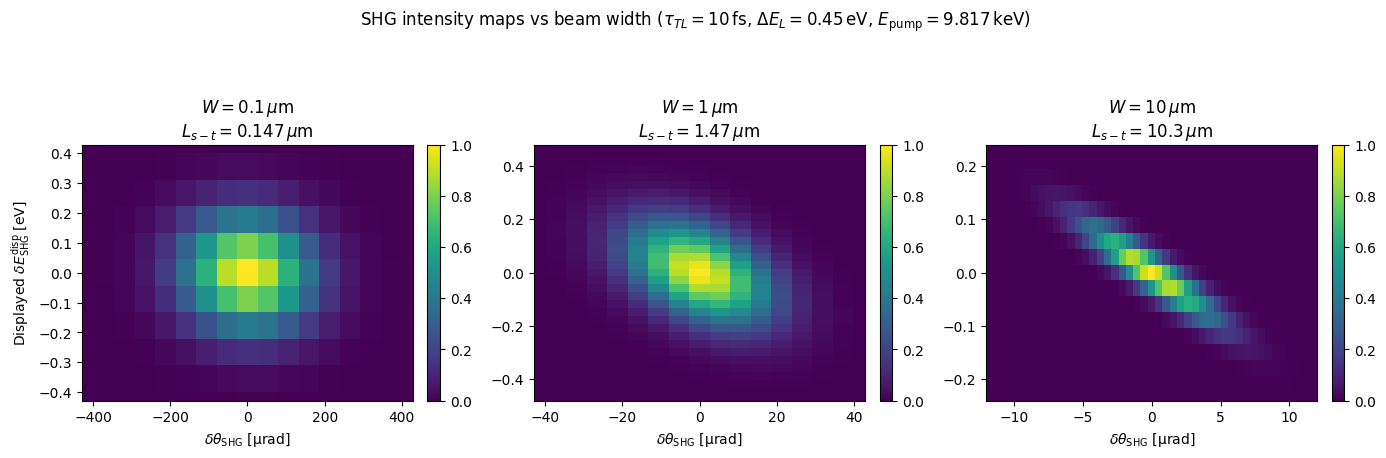

In [242]:
def compute_ishg_map(
    W_m,
    n_theta_S=121,
    n_energy_S=121,
    n_theta_L=61,
    n_omega_L=61,
    range_scale=8.0,
):
    """I_SHG map for beam width W_m [m], with adaptive SHG axes."""
    Delta_theta_W = 2.0 / (k_LASER * W_m)
    L_st_W = (np.tan(rho) ** 2 / W_m**2 + GVM**2 / TAU_TL**2) ** (-0.5)

    # Expected SHG acceptances for this W
    th_acc_z = 1.0 / (abs(k_SHG * np.sin(theta_SHG0)) * L_st_W + 1e-30)
    th_acc_x = 1.0 / (abs(k_SHG * np.cos(theta_SHG0)) * W_m + 1e-30)
    E_acc_display = float(dw_SHG_to_displayed_dE(1.0 / (L_st_W / c + 1e-30)))
    sigma_w = np.sqrt(2.0 * np.log(2.0)) / TAU_SPEC

    th_max = range_scale * max(th_acc_z, th_acc_x, Delta_theta_W)
    E_max = range_scale * max(
        E_acc_display,
        sigma_w * hb / (q * SHG_ENERGY_CALIBRATION),
        fund_E_FWHM_eV / SHG_ENERGY_CALIBRATION,
    )

    dtheta_S_axis = np.linspace(-th_max, th_max, n_theta_S)
    dE_S_eV_axis = np.linspace(-E_max, E_max, n_energy_S)
    dw_S_axis = displayed_dE_to_dw_SHG(dE_S_eV_axis)

    dth_L_ax = np.linspace(-3.0 * Delta_theta_W, 3.0 * Delta_theta_W, n_theta_L)
    dw_rel_ax = np.linspace(-3.0 * sigma_w, 3.0 * sigma_w, n_omega_L)
    DTH, DW_REL_LOCAL = np.meshgrid(dth_L_ax, dw_rel_ax, indexing="ij")

    dth_step = dth_L_ax[1] - dth_L_ax[0]
    dw_step = dw_rel_ax[1] - dw_rel_ax[0]

    I = np.zeros((n_energy_S, n_theta_S), dtype=float)
    for i_E, dw_S in enumerate(dw_S_axis):
        DW_L1 = DW_REL_LOCAL + 0.5 * dw_S
        pair_weight = laser_pair_intensity(DTH, DW_L1, dw_S, Delta_theta_W, TAU_SPEC)
        for i_th, dth_S in enumerate(dtheta_S_axis):
            env = shg_phase_envelope(DTH, DW_L1, dth_S, dw_S, L_st_W, W_m)
            I[i_E, i_th] = np.sum(env * pair_weight) * dth_step * dw_step

    I_norm = I / np.max(I) if np.max(I) > 0 else I
    return {
        "I_norm": I_norm,
        "dtheta_S": dtheta_S_axis,
        "dE_S_eV": dE_S_eV_axis,
        "W_m": W_m,
        "Delta_theta": Delta_theta_W,
        "L_st": L_st_W,
    }


def sensible_window(I_norm, dtheta_axis, dE_axis, frac=0.05, pad=1.6):
    mask = I_norm >= frac
    if np.any(mask):
        iy, ix = np.where(mask)
        th = dtheta_axis[ix]
        Ev = dE_axis[iy]
        th_max = pad * max(abs(th.min()), abs(th.max()))
        E_max = pad * max(abs(Ev.min()), abs(Ev.max()))
    else:
        th_max = abs(dtheta_axis).max()
        E_max = abs(dE_axis).max()
    return min(th_max, abs(dtheta_axis).max()), min(E_max, abs(dE_axis).max())


W_um_list = [0.1, 1.0, 10.0]
maps_by_W = {}

for W_um in W_um_list:
    print(f"Computing map for W = {W_um:g} μm ...")
    m = compute_ishg_map(W_um * 1e-6)
    th_max, E_max = sensible_window(m["I_norm"], m["dtheta_S"], m["dE_S_eV"])
    m["th_max"] = th_max
    m["E_max"] = E_max
    maps_by_W[W_um] = m
    print(
        f"  L_s-t = {m['L_st']*1e6:.4g} μm, "
        f"Δθ = {m['Delta_theta']*1e6:.4g} μrad, "
        f"window ±{th_max*1e6:.2f} μrad / ±{E_max:.3f} eV"
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, W_um in zip(axes, W_um_list):
    m = maps_by_W[W_um]
    extent = [
        m["dtheta_S"][0] * 1e6,
        m["dtheta_S"][-1] * 1e6,
        m["dE_S_eV"][0],
        m["dE_S_eV"][-1],
    ]
    im = ax.imshow(
        m["I_norm"],
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_xlim(-m["th_max"] * 1e6, m["th_max"] * 1e6)
    ax.set_ylim(-m["E_max"], m["E_max"])
    ax.set_xlabel(r"$\delta\theta_{\mathrm{SHG}}$ [μrad]")
    ax.set_title(
        rf"$W={W_um:g}\,\mu\mathrm{{m}}$"
        + "\n"
        + rf"$L_{{s-t}}={m['L_st']*1e6:.3g}\,\mu\mathrm{{m}}$"
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].set_ylabel(r"Displayed $\delta E_{\mathrm{SHG}}^{\mathrm{disp}}$ [eV]")
fig.suptitle(
    rf"SHG intensity maps vs beam width "
    rf"($\tau_{{TL}}={TAU_TL*1e15:.0f}\,\mathrm{{fs}}$, "
    rf"$\Delta E_L={fund_E_FWHM_eV:.2g}\,\mathrm{{eV}}$, "
    rf"$E_{{\mathrm{{pump}}}}={pump_photon_energy_eV/1e3:.3f}\,\mathrm{{keV}}$)",
    y=1.08,
)
fig.tight_layout()
plt.show()


## 7c. SHG angular and energy widths vs beam width $W$

For input fundamental beam widths logarithmically spaced over
$W\in[0.05,10]\,\mu\mathrm{m}$, use the corresponding
$L_{s\!-\!t}(W)$ and $\Delta\theta(W)$, and measure:

- **angular FWHM** of $I(\delta\theta_{\mathrm{SHG}},\,\delta E_{\mathrm{SHG}}^{\mathrm{disp}}=0)$
- **displayed energy FWHM** of $I(\delta\theta_{\mathrm{SHG}}=0,\,\delta E_{\mathrm{SHG}}^{\mathrm{disp}})$

with the full two-field convolution and both $\delta k_z$ and $\delta k_x$ envelopes.
The displayed energy widths are half the internal physical widths.


W =   0.050 μm | L_s-t =   0.074 μm | Δθ_FWHM =  539.669 μrad | ΔE_FWHM =   0.3180 eV
W =   0.071 μm | L_s-t =   0.105 μm | Δθ_FWHM =  379.078 μrad | ΔE_FWHM =   0.3185 eV
W =   0.101 μm | L_s-t =   0.149 μm | Δθ_FWHM =  266.276 μrad | ΔE_FWHM =   0.3178 eV
W =   0.144 μm | L_s-t =   0.213 μm | Δθ_FWHM =  187.043 μrad | ΔE_FWHM =   0.3176 eV
W =   0.205 μm | L_s-t =   0.303 μm | Δθ_FWHM =  131.391 μrad | ΔE_FWHM =   0.3164 eV
W =   0.292 μm | L_s-t =   0.431 μm | Δθ_FWHM =   92.302 μrad | ΔE_FWHM =   0.3146 eV
W =   0.416 μm | L_s-t =   0.613 μm | Δθ_FWHM =   64.850 μrad | ΔE_FWHM =   0.3109 eV
W =   0.593 μm | L_s-t =   0.872 μm | Δθ_FWHM =   45.574 μrad | ΔE_FWHM =   0.3038 eV
W =   0.844 μm | L_s-t =   1.239 μm | Δθ_FWHM =   32.042 μrad | ΔE_FWHM =   0.2909 eV
W =   1.201 μm | L_s-t =   1.757 μm | Δθ_FWHM =   22.550 μrad | ΔE_FWHM =   0.2690 eV
W =   1.710 μm | L_s-t =   2.483 μm | Δθ_FWHM =   15.900 μrad | ΔE_FWHM =   0.2367 eV
W =   2.434 μm | L_s-t =   3.482 μm | Δθ_FWHM =   11.2

,W [μm],L_s-t [μm],angular FWHM [μrad],energy FWHM [eV]
0,0.050000,0.073709,539.669017,0.318046
1,0.071182,0.104934,379.077878,0.318543
2,0.101338,0.149385,266.276253,0.317795
3,0.144270,0.212660,187.043486,0.317619
4,0.205389,0.302718,131.390878,0.316442
5,0.292402,0.430866,92.302423,0.314604
6,0.416277,0.613118,64.850319,0.310924
7,0.592631,0.872050,45.573720,0.303836
8,0.843696,1.239156,32.042408,0.290865
9,1.201124,1.757440,22.550349,0.268978


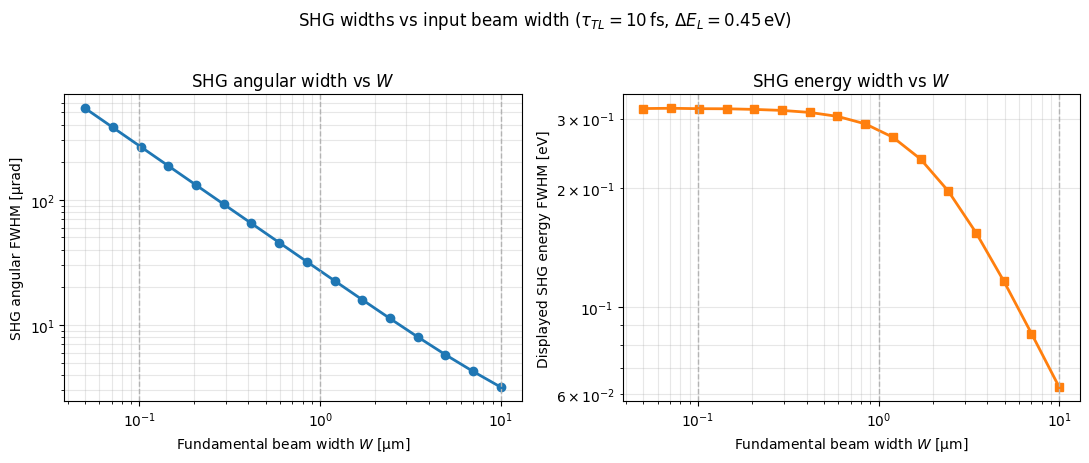

In [243]:
def fwhm_1d(x, y):
    """Full width at half-maximum of a unimodal 1D profile y(x)."""
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if not np.any(y > 0):
        return np.nan
    y = y / np.max(y)
    half = 0.5
    i_peak = int(np.argmax(y))

    i_L = i_peak
    while i_L > 0 and y[i_L] > half:
        i_L -= 1
    if i_L == i_peak:
        return np.nan
    x_L = np.interp(half, [y[i_L], y[i_L + 1]], [x[i_L], x[i_L + 1]])

    i_R = i_peak
    while i_R < len(y) - 1 and y[i_R] > half:
        i_R += 1
    if i_R == i_peak:
        return np.nan
    x_R = np.interp(half, [y[i_R], y[i_R - 1]], [x[i_R], x[i_R - 1]])
    return float(x_R - x_L)


def shg_widths_at_W(W_m, n_line=201, n_theta_L=61, n_omega_L=61):
    """SHG angular [rad] and energy [eV] FWHM for beam width W_m."""
    Delta_theta_W = 2.0 / (k_LASER * W_m)
    L_st_W = (np.tan(rho) ** 2 / W_m**2 + GVM**2 / TAU_TL**2) ** (-0.5)
    sigma_w = np.sqrt(2.0 * np.log(2.0)) / TAU_SPEC

    dth_L_ax = np.linspace(-3.0 * Delta_theta_W, 3.0 * Delta_theta_W, n_theta_L)
    dw_rel_ax = np.linspace(-3.0 * sigma_w, 3.0 * sigma_w, n_omega_L)
    DTH, DW_REL_LOCAL = np.meshgrid(dth_L_ax, dw_rel_ax, indexing="ij")
    dth_step = dth_L_ax[1] - dth_L_ax[0]
    dw_step = dw_rel_ax[1] - dw_rel_ax[0]

    th_acc = 1.0 / (abs(k_SHG * np.sin(theta_SHG0)) * L_st_W + 1e-30)
    th_acc_x = 1.0 / (abs(k_SHG * np.cos(theta_SHG0)) * W_m + 1e-30)
    E_acc_display = float(dw_SHG_to_displayed_dE(1.0 / (L_st_W / c + 1e-30)))
    th_max = 6.0 * max(th_acc, th_acc_x, Delta_theta_W)
    E_max = 6.0 * max(
        E_acc_display,
        sigma_w * hb / (q * SHG_ENERGY_CALIBRATION),
        fund_E_FWHM_eV / SHG_ENERGY_CALIBRATION,
    )

    th_axis = np.linspace(-th_max, th_max, n_line)
    E_axis = np.linspace(-E_max, E_max, n_line)

    DW_L1_ZERO = DW_REL_LOCAL
    weight_zero = laser_pair_intensity(DTH, DW_L1_ZERO, 0.0, Delta_theta_W, TAU_SPEC)
    I_th = np.empty(n_line)
    for j, dth_S in enumerate(th_axis):
        env = shg_phase_envelope(DTH, DW_L1_ZERO, dth_S, 0.0, L_st_W, W_m)
        I_th[j] = np.sum(env * weight_zero) * dth_step * dw_step

    I_E = np.empty(n_line)
    for j, dE in enumerate(E_axis):
        dw_S = float(displayed_dE_to_dw_SHG(dE))
        DW_L1 = DW_REL_LOCAL + 0.5 * dw_S
        pair_weight = laser_pair_intensity(DTH, DW_L1, dw_S, Delta_theta_W, TAU_SPEC)
        env = shg_phase_envelope(DTH, DW_L1, 0.0, dw_S, L_st_W, W_m)
        I_E[j] = np.sum(env * pair_weight) * dth_step * dw_step

    return {
        "ang_FWHM_rad": fwhm_1d(th_axis, I_th),
        "ene_FWHM_eV": fwhm_1d(E_axis, I_E),
        "L_st": L_st_W,
        "Delta_theta": Delta_theta_W,
    }


W_um_scan = np.logspace(np.log10(0.05), np.log10(10.0), 16)
ang_FWHM_urad = np.empty_like(W_um_scan)
ene_FWHM_eV = np.empty_like(W_um_scan)
L_st_of_W_um = np.empty_like(W_um_scan)

for i, W_um in enumerate(W_um_scan):
    out = shg_widths_at_W(W_um * 1e-6)
    ang_FWHM_urad[i] = out["ang_FWHM_rad"] * 1e6
    ene_FWHM_eV[i] = out["ene_FWHM_eV"]
    L_st_of_W_um[i] = out["L_st"] * 1e6
    print(
        f"W = {W_um:7.3f} μm | L_s-t = {L_st_of_W_um[i]:7.3f} μm | "
        f"Δθ_FWHM = {ang_FWHM_urad[i]:8.3f} μrad | "
        f"ΔE_FWHM = {ene_FWHM_eV[i]:8.4f} eV"
    )

width_vs_W = pd.DataFrame(
    {
        "W [μm]": W_um_scan,
        "L_s-t [μm]": L_st_of_W_um,
        "angular FWHM [μrad]": ang_FWHM_urad,
        "energy FWHM [eV]": ene_FWHM_eV,
    }
)
try:
    from IPython.display import display
    display(width_vs_W)
except ImportError:
    print(width_vs_W.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].loglog(W_um_scan, ang_FWHM_urad, "o-", lw=2, ms=6)
for Wmark in (0.1, 1.0, 10.0):
    axes[0].axvline(Wmark, color="0.7", ls="--", lw=1)
axes[0].set_xlabel(r"Fundamental beam width $W$ [μm]")
axes[0].set_ylabel(r"SHG angular FWHM [μrad]")
axes[0].set_title(r"SHG angular width vs $W$")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].loglog(W_um_scan, ene_FWHM_eV, "s-", color="C1", lw=2, ms=6)
for Wmark in (0.1, 1.0, 10.0):
    axes[1].axvline(Wmark, color="0.7", ls="--", lw=1)
axes[1].set_xlabel(r"Fundamental beam width $W$ [μm]")
axes[1].set_ylabel(r"Displayed SHG energy FWHM [eV]")
axes[1].set_title(r"SHG energy width vs $W$")
axes[1].grid(True, which="both", alpha=0.3)

fig.suptitle(
    rf"SHG widths vs input beam width "
    rf"($\tau_{{TL}}={TAU_TL*1e15:.0f}\,\mathrm{{fs}}$, "
    rf"$\Delta E_L={fund_E_FWHM_eV:.2g}\,\mathrm{{eV}}$)",
    y=1.02,
)
fig.tight_layout()
plt.show()


## 7d. SHG widths vs fundamental energy width $\Delta E_L$

For each beam width $W\in\{0.1,1,10\}\,\mu\mathrm{m}$, sweep the fundamental
intensity FWHM $\Delta E_L$ and plot:

- SHG **angular** FWHM vs $\Delta E_L$
- SHG **energy** FWHM vs $\Delta E_L$

At each point, $L_{s\!-\!t}=L_{s\!-\!t}(W)$ (with fixed $\tau_{TL}$) and
$\tau_{\mathrm{spec}}$ is set from the FWHM of each fundamental field, $\Delta E_L$.
The two fields are convolved, and the plotted SHG energy FWHM uses the calibrated displayed axis
$\delta E_{\mathrm{SHG}}^{\mathrm{physical}}=2\delta E_{\mathrm{SHG}}^{\mathrm{disp}}$.


=== W = 0.1 μm ===
  ΔE_L =  0.050 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.0413 eV
  ΔE_L =  0.070 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.0478 eV
  ΔE_L =  0.098 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.0661 eV
  ΔE_L =  0.137 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.1007 eV
  ΔE_L =  0.191 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.1361 eV
  ΔE_L =  0.267 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.1909 eV
  ΔE_L =  0.374 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.2654 eV
  ΔE_L =  0.523 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.3698 eV
  ΔE_L =  0.731 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.5159 eV
  ΔE_L =  1.023 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.7181 eV
  ΔE_L =  1.430 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   0.9977 eV
  ΔE_L =  2.000 eV | Δθ_SHG =  269.840 μrad | ΔE_SHG =   1.3775 eV
=== W = 1 μm ===
  ΔE_L =  0.050 eV | Δθ_SHG =   27.054 μrad | ΔE_SHG =   0.0354 eV
  ΔE_L =  0.070 eV | Δθ_SHG =   27.054 μrad | ΔE_SHG =   0.0493 eV
  ΔE_L =  0.098 eV | Δθ_SH

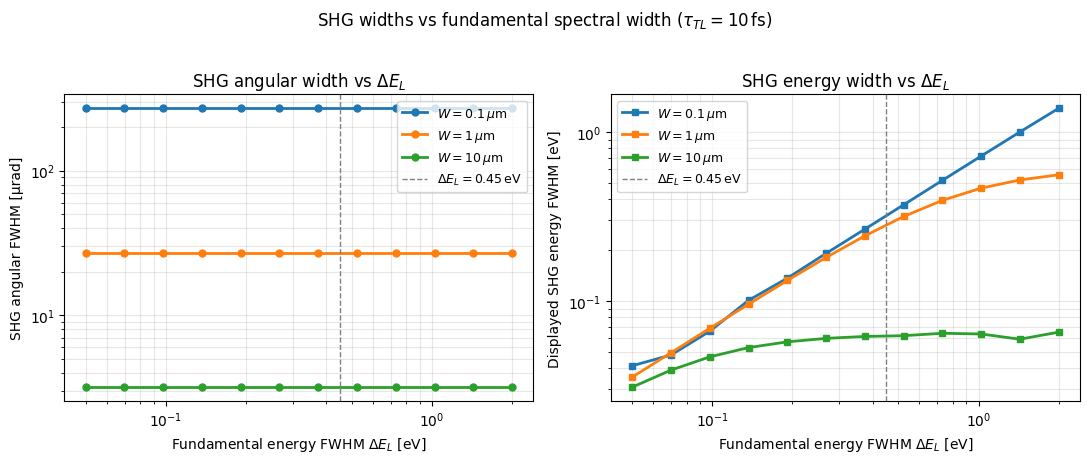

In [244]:
if "fwhm_1d" not in globals():
    def fwhm_1d(x, y):
        y = np.asarray(y, dtype=float)
        x = np.asarray(x, dtype=float)
        if not np.any(y > 0):
            return np.nan
        y = y / np.max(y)
        half = 0.5
        i_peak = int(np.argmax(y))
        i_L = i_peak
        while i_L > 0 and y[i_L] > half:
            i_L -= 1
        if i_L == i_peak:
            return np.nan
        x_L = np.interp(half, [y[i_L], y[i_L + 1]], [x[i_L], x[i_L + 1]])
        i_R = i_peak
        while i_R < len(y) - 1 and y[i_R] > half:
            i_R += 1
        if i_R == i_peak:
            return np.nan
        x_R = np.interp(half, [y[i_R], y[i_R - 1]], [x[i_R], x[i_R - 1]])
        return float(x_R - x_L)


def shg_widths_at_W_and_dE(
    W_m,
    fund_E_FWHM_eV_local,
    n_line=201,
    n_theta_L=61,
    n_omega_L=61,
):
    """SHG angular [rad] and energy [eV] FWHM for given W and ΔE_L."""
    Delta_theta_W = 2.0 / (k_LASER * W_m)
    L_st_W = (np.tan(rho) ** 2 / W_m**2 + GVM**2 / TAU_TL**2) ** (-0.5)

    # Spectral scale from independent fundamental energy FWHM
    d_omega_FWHM = fund_E_FWHM_eV_local * q / hb
    tau_spec = 2.0 * np.sqrt(2.0) * np.log(2.0) / d_omega_FWHM
    sigma_w = np.sqrt(2.0 * np.log(2.0)) / tau_spec

    dth_L_ax = np.linspace(-3.0 * Delta_theta_W, 3.0 * Delta_theta_W, n_theta_L)
    dw_rel_ax = np.linspace(-3.0 * sigma_w, 3.0 * sigma_w, n_omega_L)
    DTH, DW_REL_LOCAL = np.meshgrid(dth_L_ax, dw_rel_ax, indexing="ij")
    dth_step = dth_L_ax[1] - dth_L_ax[0]
    dw_step = dw_rel_ax[1] - dw_rel_ax[0]

    th_acc = 1.0 / (abs(k_SHG * np.sin(theta_SHG0)) * L_st_W + 1e-30)
    th_acc_x = 1.0 / (abs(k_SHG * np.cos(theta_SHG0)) * W_m + 1e-30)
    E_acc_display = float(dw_SHG_to_displayed_dE(1.0 / (L_st_W / c + 1e-30)))
    th_max = 6.0 * max(th_acc, th_acc_x, Delta_theta_W)
    E_max = 6.0 * max(
        E_acc_display,
        sigma_w * hb / (q * SHG_ENERGY_CALIBRATION),
        fund_E_FWHM_eV_local / SHG_ENERGY_CALIBRATION,
    )

    th_axis = np.linspace(-th_max, th_max, n_line)
    E_axis = np.linspace(-E_max, E_max, n_line)

    weight_zero = laser_pair_intensity(DTH, DW_REL_LOCAL, 0.0, Delta_theta_W, tau_spec)
    I_th = np.empty(n_line)
    for j, dth_S in enumerate(th_axis):
        env = shg_phase_envelope(DTH, DW_REL_LOCAL, dth_S, 0.0, L_st_W, W_m)
        I_th[j] = np.sum(env * weight_zero) * dth_step * dw_step

    I_E = np.empty(n_line)
    for j, dE in enumerate(E_axis):
        dw_S = float(displayed_dE_to_dw_SHG(dE))
        DW_L1 = DW_REL_LOCAL + 0.5 * dw_S
        pair_weight = laser_pair_intensity(DTH, DW_L1, dw_S, Delta_theta_W, tau_spec)
        env = shg_phase_envelope(DTH, DW_L1, 0.0, dw_S, L_st_W, W_m)
        I_E[j] = np.sum(env * pair_weight) * dth_step * dw_step

    return fwhm_1d(th_axis, I_th), fwhm_1d(E_axis, I_E)


W_um_for_dE_scan = [0.1, 1.0, 10.0]
dE_L_scan_eV = np.logspace(np.log10(0.05), np.log10(2.0), 12)

ang_vs_dE = {}
ene_vs_dE = {}

for W_um in W_um_for_dE_scan:
    print(f"=== W = {W_um:g} μm ===")
    ang = np.empty_like(dE_L_scan_eV)
    ene = np.empty_like(dE_L_scan_eV)
    for i, dE_L in enumerate(dE_L_scan_eV):
        a_rad, e_eV = shg_widths_at_W_and_dE(W_um * 1e-6, float(dE_L))
        ang[i] = a_rad * 1e6
        ene[i] = e_eV
        print(
            f"  ΔE_L = {dE_L:6.3f} eV | "
            f"Δθ_SHG = {ang[i]:8.3f} μrad | "
            f"ΔE_SHG = {ene[i]:8.4f} eV"
        )
    ang_vs_dE[W_um] = ang
    ene_vs_dE[W_um] = ene

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for W_um in W_um_for_dE_scan:
    axes[0].loglog(
        dE_L_scan_eV, ang_vs_dE[W_um], "o-", lw=2, ms=5,
        label=rf"$W={W_um:g}\,\mu\mathrm{{m}}$",
    )
    axes[1].loglog(
        dE_L_scan_eV, ene_vs_dE[W_um], "s-", lw=2, ms=5,
        label=rf"$W={W_um:g}\,\mu\mathrm{{m}}$",
    )

axes[0].axvline(0.45, color="0.5", ls="--", lw=1, label=r"$\Delta E_L=0.45\,\mathrm{eV}$")
axes[1].axvline(0.45, color="0.5", ls="--", lw=1, label=r"$\Delta E_L=0.45\,\mathrm{eV}$")

axes[0].set_xlabel(r"Fundamental energy FWHM $\Delta E_L$ [eV]")
axes[0].set_ylabel(r"SHG angular FWHM [μrad]")
axes[0].set_title(r"SHG angular width vs $\Delta E_L$")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].set_xlabel(r"Fundamental energy FWHM $\Delta E_L$ [eV]")
axes[1].set_ylabel(r"Displayed SHG energy FWHM [eV]")
axes[1].set_title(r"SHG energy width vs $\Delta E_L$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle(
    rf"SHG widths vs fundamental spectral width "
    rf"($\tau_{{TL}}={TAU_TL*1e15:.0f}\,\mathrm{{fs}}$)",
    y=1.02,
)
fig.tight_layout()
plt.show()


## 8. Optional: save map arrays

In [245]:
out = HERE / "shg_intensity_map_tau10fs.npz"
np.savez(
    out,
    dtheta_SHG_rad=dtheta_SHG_axis,
    dE_SHG_eV=dE_SHG_axis_eV,  # backward-compatible alias: displayed/calibrated axis
    dE_SHG_displayed_eV=dE_SHG_axis_eV,
    dE_SHG_physical_eV=SHG_ENERGY_CALIBRATION * dE_SHG_axis_eV,
    SHG_energy_calibration=SHG_ENERGY_CALIBRATION,
    I_SHG=I_SHG,
    I_SHG_norm=I_SHG_norm,
    TAU_TL_s=TAU_TL,
    TAU_SPEC_s=TAU_SPEC,
    fund_E_FWHM_eV=fund_E_FWHM_eV,
    W_m=W,
    L_st_m=L_st,
    GVM_s_per_m=GVM,
    theta_LASER0=theta_LASER0,
    theta_SHG0=theta_SHG0,
    pump_photon_energy_eV=pump_photon_energy_eV,
)
print("saved:", out)

saved: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\shg_intensity_map_tau10fs.npz


## 9. Angular and energy widths vs $L_{s\!-\!t}$

Uses **the same two-field convolution** as the intensity map: integrate over
$\delta\theta_L$ and $\delta\omega_{L,1}$, with
$\delta\omega_{L,2}=\delta\omega_{\mathrm{SHG}}-\delta\omega_{L,1}$, including both
$\delta k_z$ and $\delta k_x$ envelopes. Energy scans and FWHM values use the calibrated displayed axis,
which is half the internal physical SHG-energy detuning.

For 10 logarithmically spaced values $L_{s\!-\!t}\in[0.05,\,10]\,\mu\mathrm{m}$:

- **Angular width:** FWHM of
  $I_{\mathrm{SHG}}(\delta\theta_{\mathrm{SHG}},\,\delta E_{\mathrm{SHG}}=0)$
  (scan $\delta\theta_{\mathrm{SHG}}$; hold $\delta E_{\mathrm{SHG}}=0$; integrate over laser deviations)
- **Energy width:** FWHM of
  $I_{\mathrm{SHG}}(\delta\theta_{\mathrm{SHG}}=0,\,\delta E_{\mathrm{SHG}})$
  (scan $\delta E_{\mathrm{SHG}}$; hold $\delta\theta_{\mathrm{SHG}}=0$; integrate over laser deviations)

$L_{s\!-\!t}$ is varied in the $\delta k_z$ envelope; the $\delta k_x$ envelope keeps the fixed beam width $W$.


In [246]:
def fwhm(x, y):
    """Full width at half-maximum of a unimodal 1D profile y(x)."""
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if not np.any(y > 0):
        return np.nan
    y = y / np.max(y)
    half = 0.5
    i_peak = int(np.argmax(y))

    i_L = i_peak
    while i_L > 0 and y[i_L] > half:
        i_L -= 1
    if i_L == i_peak:
        return np.nan
    x_L = np.interp(half, [y[i_L], y[i_L + 1]], [x[i_L], x[i_L + 1]])

    i_R = i_peak
    while i_R < len(y) - 1 and y[i_R] > half:
        i_R += 1
    if i_R == i_peak:
        return np.nan
    x_R = np.interp(half, [y[i_R], y[i_R - 1]], [x[i_R], x[i_R - 1]])

    return float(x_R - x_L)


def ishg_lineout_theta(dtheta_S_axis, L_st_val, dth_L_grid, dw_rel_grid, dth_step, dw_step):
    """I_SHG(δθ_S, displayed δE_S=0), with the two-field convolution."""
    pair_weight = laser_pair_intensity(dth_L_grid, dw_rel_grid, 0.0)
    out = np.empty(len(dtheta_S_axis), dtype=float)
    for i, dth_S in enumerate(dtheta_S_axis):
        env = shg_phase_envelope(dth_L_grid, dw_rel_grid, dth_S, 0.0, L_st_val, W)
        out[i] = np.sum(env * pair_weight) * dth_step * dw_step
    return out


def ishg_lineout_energy(dE_S_eV_axis, L_st_val, dth_L_grid, dw_rel_grid, dth_step, dw_step):
    """I_SHG(δθ_S=0, displayed δE_S), with the two-field convolution."""
    dw_S_axis = displayed_dE_to_dw_SHG(dE_S_eV_axis)
    out = np.empty(len(dw_S_axis), dtype=float)
    for i, dw_S in enumerate(dw_S_axis):
        dw_L1_grid = dw_rel_grid + 0.5 * dw_S
        pair_weight = laser_pair_intensity(dth_L_grid, dw_L1_grid, dw_S)
        env = shg_phase_envelope(dth_L_grid, dw_L1_grid, 0.0, dw_S, L_st_val, W)
        out[i] = np.sum(env * pair_weight) * dth_step * dw_step
    return out


# Laser integration grid (reuse map grid if present, else build)
if "DTH_L" not in globals():
    _sig_w = np.sqrt(2.0 * np.log(2.0)) / TAU_SPEC
    _dth = np.linspace(-3.0 * Delta_theta, 3.0 * Delta_theta, 61)
    _dw = np.linspace(-3.0 * _sig_w, 3.0 * _sig_w, 61)
    DTH_L, DW_REL = np.meshgrid(_dth, _dw, indexing="ij")
    DW_L = DW_REL
    dth_L = _dth[1] - _dth[0]
    dw_L = _dw[1] - _dw[0]

if "DW_REL" not in globals():
    DW_REL = DW_L

if "sigma_w_L" not in globals():
    sigma_w_L = np.sqrt(2.0 * np.log(2.0)) / TAU_SPEC

L_st_scan_um = np.logspace(np.log10(0.05), np.log10(10.0), 10)  # 0.05 → 10 μm
L_st_scan_m = L_st_scan_um * 1e-6

N_LINE = 201
angular_fwhm_urad = np.empty(len(L_st_scan_m))
energy_fwhm_eV = np.empty(len(L_st_scan_m))

for i, Lval in enumerate(L_st_scan_m):
    # Adaptive half-range ~ several acceptance widths for this L_s-t
    th_acc = 1.0 / (abs(k_SHG * np.sin(theta_SHG0)) * Lval + 1e-30)
    E_acc_display = float(dw_SHG_to_displayed_dE(1.0 / (Lval / c + 1e-30)))
    # Also account for transverse acceptance ~ 1/(k W) scale
    th_acc_x = 1.0 / (abs(k_SHG * np.cos(theta_SHG0)) * W + 1e-30)
    th_max = 6.0 * max(th_acc, th_acc_x, Delta_theta)
    E_max = 6.0 * max(
        E_acc_display,
        sigma_w_L * hb / (q * SHG_ENERGY_CALIBRATION),
    )

    th_axis = np.linspace(-th_max, th_max, N_LINE)
    E_axis = np.linspace(-E_max, E_max, N_LINE)

    I_th = ishg_lineout_theta(th_axis, Lval, DTH_L, DW_REL, dth_L, dw_L)
    I_E = ishg_lineout_energy(E_axis, Lval, DTH_L, DW_REL, dth_L, dw_L)

    angular_fwhm_urad[i] = fwhm(th_axis, I_th) * 1e6
    energy_fwhm_eV[i] = fwhm(E_axis, I_E)

    print(
        f"L_s-t = {L_st_scan_um[i]:8.3f} μm | "
        f"Δθ_FWHM = {angular_fwhm_urad[i]:8.3f} μrad | "
        f"ΔE_FWHM = {energy_fwhm_eV[i]:8.4f} eV"
    )

width_vs_Lst = pd.DataFrame(
    {
        "L_s-t [μm]": L_st_scan_um,
        "angular FWHM [μrad]": angular_fwhm_urad,
        "energy FWHM [eV]": energy_fwhm_eV,
    }
)
try:
    from IPython.display import display
    display(width_vs_Lst)
except ImportError:
    print(width_vs_Lst.to_string(index=False))


L_s-t =    0.050 μm | Δθ_FWHM =   44.025 μrad | ΔE_FWHM =   0.2989 eV
L_s-t =    0.090 μm | Δθ_FWHM =   40.234 μrad | ΔE_FWHM =   0.2898 eV
L_s-t =    0.162 μm | Δθ_FWHM =   41.666 μrad | ΔE_FWHM =   0.2871 eV
L_s-t =    0.292 μm | Δθ_FWHM =   40.454 μrad | ΔE_FWHM =   0.2869 eV
L_s-t =    0.527 μm | Δθ_FWHM =   38.072 μrad | ΔE_FWHM =   0.2863 eV
L_s-t =    0.949 μm | Δθ_FWHM =   32.757 μrad | ΔE_FWHM =   0.2846 eV
L_s-t =    1.710 μm | Δθ_FWHM =   24.938 μrad | ΔE_FWHM =   0.2800 eV
L_s-t =    3.081 μm | Δθ_FWHM =   18.041 μrad | ΔE_FWHM =   0.2707 eV
L_s-t =    5.550 μm | Δθ_FWHM =   14.093 μrad | ΔE_FWHM =   0.2597 eV
L_s-t =   10.000 μm | Δθ_FWHM =   12.522 μrad | ΔE_FWHM =   0.2526 eV


,L_s-t [μm],angular FWHM [μrad],energy FWHM [eV]
0,0.050000,44.025475,0.298929
1,0.090082,40.234364,0.289785
2,0.162297,41.665888,0.287095
3,0.292402,40.454128,0.286910
4,0.526805,38.072141,0.286310
5,0.949118,32.756859,0.284592
6,1.709976,24.938314,0.279979
7,3.080775,18.041014,0.270711
8,5.550473,14.092951,0.259675
9,10.000000,12.522204,0.252561


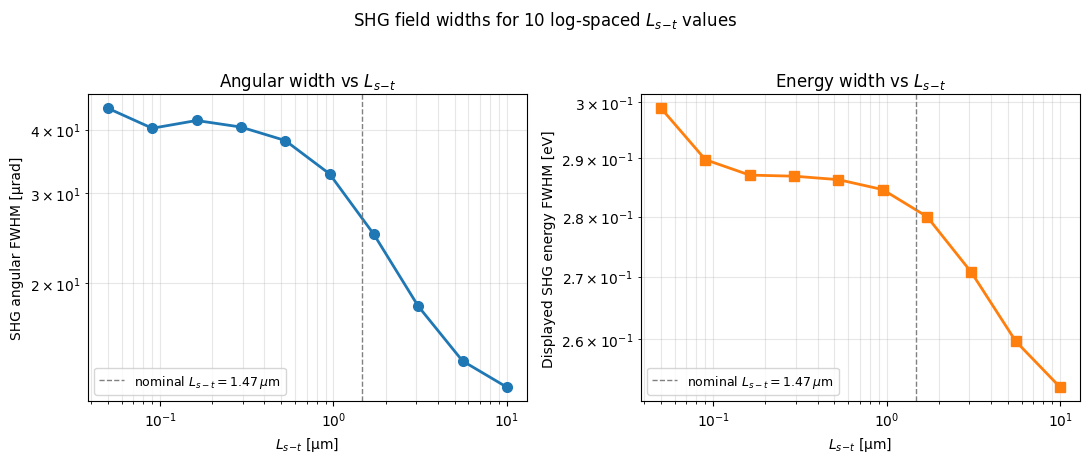

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].loglog(L_st_scan_um, angular_fwhm_urad, "o-", lw=2, ms=7)
axes[0].axvline(L_st * 1e6, color="0.5", ls="--", lw=1, label=rf"nominal $L_{{s-t}}={L_st*1e6:.2f}\,\mu$m")
axes[0].set_xlabel(r"$L_{s\!-\!t}$ [μm]")
axes[0].set_ylabel(r"SHG angular FWHM [μrad]")
axes[0].set_title(r"Angular width vs $L_{s\!-\!t}$")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].loglog(L_st_scan_um, energy_fwhm_eV, "s-", color="C1", lw=2, ms=7)
axes[1].axvline(L_st * 1e6, color="0.5", ls="--", lw=1, label=rf"nominal $L_{{s-t}}={L_st*1e6:.2f}\,\mu$m")
axes[1].set_xlabel(r"$L_{s\!-\!t}$ [μm]")
axes[1].set_ylabel(r"Displayed SHG energy FWHM [eV]")
axes[1].set_title(r"Energy width vs $L_{s\!-\!t}$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle(r"SHG field widths for 10 log-spaced $L_{s\!-\!t}$ values", y=1.02)
fig.tight_layout()
plt.show()


## 10. Analytical SHG widths (Yudovich approx.)

Closed-form FWHM approximations from Shimon Yudovich's SHG paper, evaluated on the **same**
$L_{s\!-\!t}$ grid as Sec. 9:

$$
\Delta\theta_{\mathrm{FWHM}}
=
\frac{2\sqrt{\ln 2}}{2\pi\, k_{\omega}\, L_{s\!-\!t}\,\tan(2\theta_B)}
$$

$$
\Delta E_{\mathrm{FWHM}}^{\mathrm{physical}}
=
\frac{\sqrt{\ln 2}\,\cos(2\theta_B)}{L_{s\!-\!t}\,\sin^{2}\theta_B}\,\hbar c,
\qquad
\Delta E_{\mathrm{FWHM}}^{\mathrm{disp}}
=\frac{\Delta E_{\mathrm{FWHM}}^{\mathrm{physical}}}{2}.
$$

Here $k_{\omega}=k_{\mathrm{LASER}}$ and $\theta_B$ is the Bragg angle from the base geometry.
The plotted analytical energy widths use the calibrated displayed axis.

In [248]:
# Same L_s-t samples as the numerical width sweep (Sec. 9)
if "L_st_scan_um" not in globals():
    L_st_scan_um = np.logspace(np.log10(0.05), np.log10(10.0), 10)
L_st_scan_m_an = L_st_scan_um * 1e-6

k_omega = k_LASER  # fundamental wave number k_ω
two_theta_B = 2.0 * theta_B

# Angular FWHM [rad] → μrad
dtheta_FWHM_an_rad = (
    2.0 * np.sqrt(np.log(2.0))
    / (2.0 * np.pi * k_omega * L_st_scan_m_an * np.tan(two_theta_B))
)
dtheta_FWHM_an_urad = dtheta_FWHM_an_rad * 1e6

# Physical energy FWHM [J], then convert to the calibrated displayed eV axis.
dE_FWHM_an_J = (
    np.sqrt(np.log(2.0))
    * np.cos(two_theta_B)
    / (L_st_scan_m_an * np.sin(theta_B) ** 2)
    * hb
    * c
)
dE_FWHM_an_eV = dE_FWHM_an_J / (q * SHG_ENERGY_CALIBRATION)

yudovich_widths = pd.DataFrame(
    {
        "L_s-t [μm]": L_st_scan_um,
        "Δθ_FWHM analytic [μrad]": dtheta_FWHM_an_urad,
        "ΔE_FWHM analytic [eV]": dE_FWHM_an_eV,
    }
)
try:
    from IPython.display import display
    display(yudovich_widths)
except ImportError:
    print(yudovich_widths.to_string(index=False))

print(f"θ_B = {theta_B:.6f} rad ({np.degrees(theta_B):.4f} deg)")
print(f"k_ω = {k_omega:.6e} 1/m")


,L_s-t [μm],Δθ_FWHM analytic [μrad],ΔE_FWHM analytic [eV]
0,0.050000,157.076003,15.771146
1,0.090082,87.184613,8.753732
2,0.162297,48.391585,4.858735
3,0.292402,26.859619,2.696828
4,0.526805,14.908359,1.496867
5,0.949118,8.274845,0.830832
6,1.709976,4.592930,0.461151
7,3.080775,2.549294,0.255961
8,5.550473,1.414979,0.142070
9,10.000000,0.785380,0.078856


θ_B = 0.298017 rad (17.0751 deg)
k_ω = 4.974406e+10 1/m


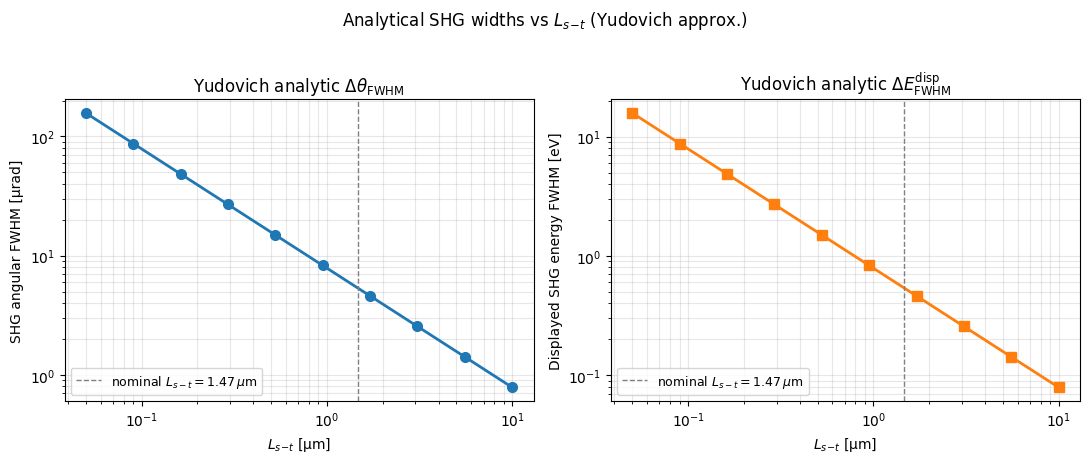

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].loglog(L_st_scan_um, dtheta_FWHM_an_urad, "o-", lw=2, ms=7, color="C0")
axes[0].axvline(
    L_st * 1e6, color="0.5", ls="--", lw=1,
    label=rf"nominal $L_{{s-t}}={L_st*1e6:.2f}\,\mu$m",
)
axes[0].set_xlabel(r"$L_{s\!-\!t}$ [μm]")
axes[0].set_ylabel(r"SHG angular FWHM [μrad]")
axes[0].set_title(r"Yudovich analytic $\Delta\theta_{\mathrm{FWHM}}$")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].loglog(L_st_scan_um, dE_FWHM_an_eV, "s-", lw=2, ms=7, color="C1")
axes[1].axvline(
    L_st * 1e6, color="0.5", ls="--", lw=1,
    label=rf"nominal $L_{{s-t}}={L_st*1e6:.2f}\,\mu$m",
)
axes[1].set_xlabel(r"$L_{s\!-\!t}$ [μm]")
axes[1].set_ylabel(r"Displayed SHG energy FWHM [eV]")
axes[1].set_title(r"Yudovich analytic $\Delta E_{\mathrm{FWHM}}^{\mathrm{disp}}$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle(
    r"Analytical SHG widths vs $L_{s\!-\!t}$ (Yudovich approx.)",
    y=1.02,
)
fig.tight_layout()
plt.show()


## 11. $L_{s\!-\!t}$ vs beam width $W$

Using the theory definition

$$
L_{s\!-\!t}(W,\tau_{TL})
=
\left(
\frac{\tan^{2}\rho}{W^{2}}
+
\frac{\mathrm{GVM}^{2}}{\tau_{TL}^{2}}
\right)^{-1/2}
$$

with fixed geometry $(\rho,\mathrm{GVM})$ from the base phase-matched solution, plot $L_{s\!-\!t}$ versus $W$ for

- $\tau_{TL}=10\,\mathrm{fs}$
- $\tau_{TL}=0.5\,\mathrm{fs}$

τ_TL = 10 fs, W = 1 μm → L_s-t = 1.4665 μm
τ_TL = 0.5 fs, W = 1 μm → L_s-t = 0.6465 μm


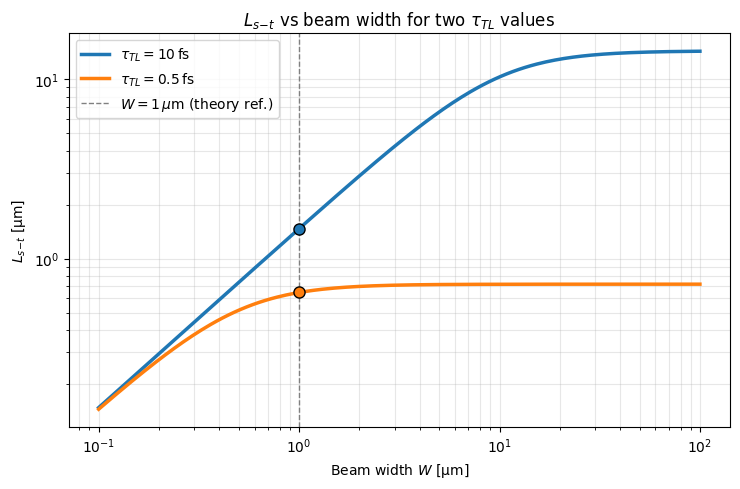

In [250]:
# Beam-width scan (same ρ, GVM as the base geometry)
W_um_axis = np.logspace(np.log10(0.1), np.log10(100.0), 200)  # 0.1 → 100 μm
W_m_axis = W_um_axis * 1e-6

TAU_TL_list_fs = [10.0, 0.5]
L_st_vs_W = {}

for tau_fs in TAU_TL_list_fs:
    tau_s = tau_fs * 1e-15
    L_st_vs_W[tau_fs] = (
        np.tan(rho) ** 2 / W_m_axis**2 + GVM**2 / tau_s**2
    ) ** (-0.5)

fig, ax = plt.subplots(figsize=(7.5, 5))
for tau_fs, color, marker in zip(TAU_TL_list_fs, ["C0", "C1"], ["o", "s"]):
    ax.loglog(
        W_um_axis,
        L_st_vs_W[tau_fs] * 1e6,
        "-",
        lw=2.5,
        color=color,
        label=rf"$\tau_{{TL}}={tau_fs:g}\,\mathrm{{fs}}$",
    )

# Mark the theory reference point W = 1 μm used elsewhere in the notebook
ax.axvline(1.0, color="0.5", ls="--", lw=1, label=r"$W=1\,\mu\mathrm{m}$ (theory ref.)")
for tau_fs, color in zip(TAU_TL_list_fs, ["C0", "C1"]):
    L_at_1um = (np.tan(rho) ** 2 / (1e-6) ** 2 + GVM**2 / (tau_fs * 1e-15) ** 2) ** (-0.5)
    ax.plot(1.0, L_at_1um * 1e6, marker="o", ms=8, color=color, markeredgecolor="k", zorder=5)
    print(f"τ_TL = {tau_fs:g} fs, W = 1 μm → L_s-t = {L_at_1um*1e6:.4f} μm")

ax.set_xlabel(r"Beam width $W$ [μm]")
ax.set_ylabel(r"$L_{s\!-\!t}$ [μm]")
ax.set_title(r"$L_{s\!-\!t}$ vs beam width for two $\tau_{TL}$ values")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()
